# 5-5 Market Meanness Index 濾網

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/5-5_mmi_filter.ipynb)

**對應影片**：第 5 章 單元 5-5【策略濾網】使用 Market Meanness Index 濾網、5-6【策略濾網】將 Filter 打包重複再利用

**和影片的差異**

- 資料改從 Binance 公開資料端點下載（`data-api.binance.vision`，不需金鑰、Colab 可用），`get_all_binance` 的寫法和影片一樣。
- 1 小時 K 線從影片錄製時的約 2.8 萬根，成長到現在超過 8 萬根。為了讓 Colab 免費版幾分鐘內跑完最佳化，預設只用 `START` 之後的資料（和影片的資料量相近）；想用完整歷史，把 `START` 改成 `None`。
- 「畫出 MMI」改看最近一個月（影片是 2020 年 10 月）。
- 最後「最終策略」沿用影片選的參數；資料不同，你的最佳參數可能不一樣，請依自己的最佳化結果調整。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
# 最佳化使用的資料起點；改成 None 使用全部歷史（需要較多記憶體與時間）
START = '2023-01-01'

In [4]:
import finlab_crypto

finlab_crypto.setup()
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '1h').loc[START:]

BTCUSDT 1h: 79678 candles (2017-08-17 ~ 2026-09-24 09:00 UTC)


## 均線策略（沒有濾網）

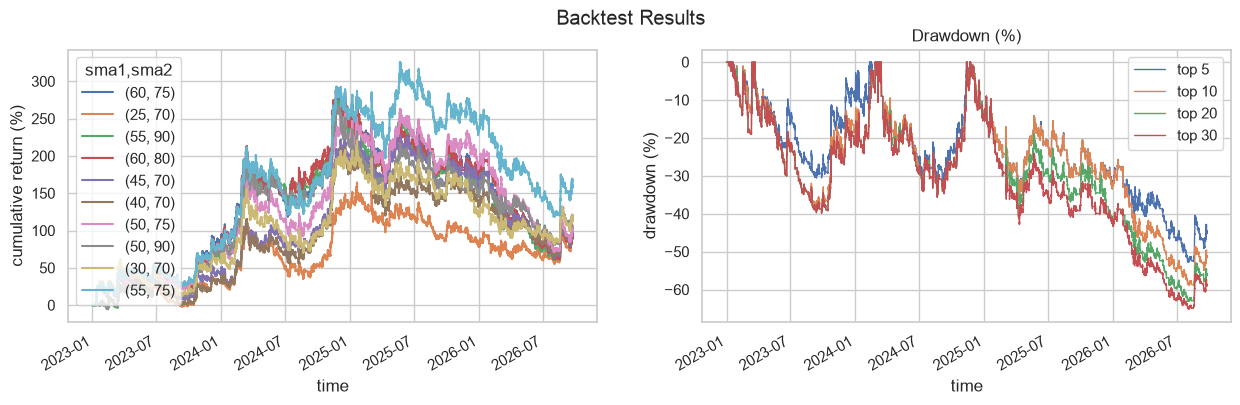

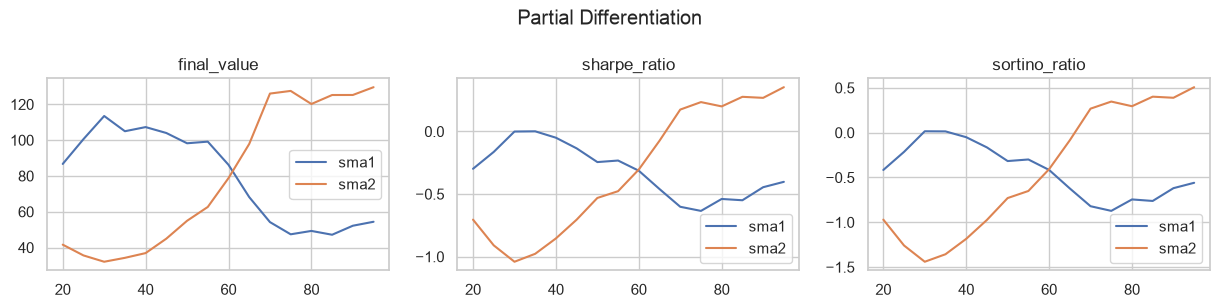

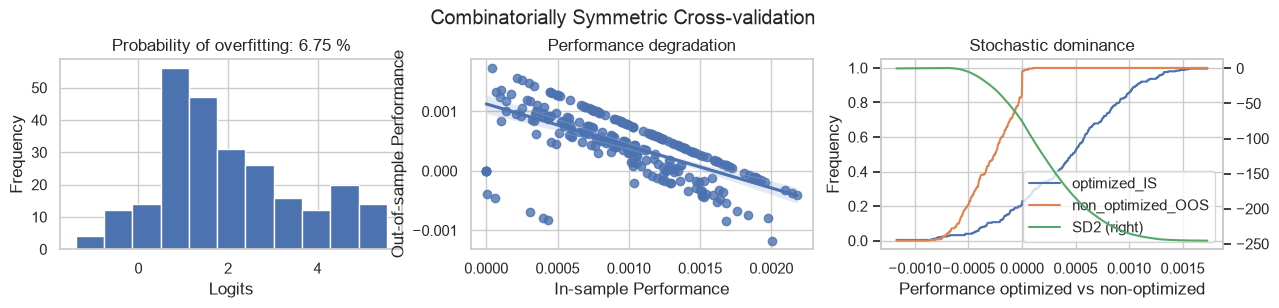

In [5]:
import numpy as np
from finlab_crypto import Strategy


@Strategy(sma1=20, sma2=60)
def sma_strategy(ohlcv):
    close = ohlcv.close
    sma20 = close.rolling(sma_strategy.sma1).mean()
    sma60 = close.rolling(sma_strategy.sma2).mean()

    entries = (sma20 > sma60) & (sma20.shift() < sma60.shift())
    exits = (sma20 < sma60) & (sma20.shift() > sma60.shift())

    figures = {
        'overlaps': {
            'sma20': sma20,
            'sma60': sma60,
        }
    }
    return entries, exits, figures


step = 20 if QUICK_RUN else 5
variables = {'sma1': np.arange(20, 100, step), 'sma2': np.arange(20, 100, step)}
portfolio = sma_strategy.backtest(ohlcv, variables=variables, freq='1h', plot=True)

## MMI 濾網

[Market Meanness Index](https://financial-hacker.com/the-market-meanness-index/)：
價格「連續兩根都在中位數之上」的比例。比例高代表走勢有延續性（趨勢盤），比例低代表來回震盪。
除以期數（這裡是 20）讓數值落在 0 ~ 1 之間。

In [6]:
median = ohlcv.close.rolling(20).median()
p1 = ohlcv.close > median
p2 = ohlcv.close.shift() > median

mmi = (p1 & p2).rolling(20).sum() / 20

### 畫出最近一個月

<Axes: >

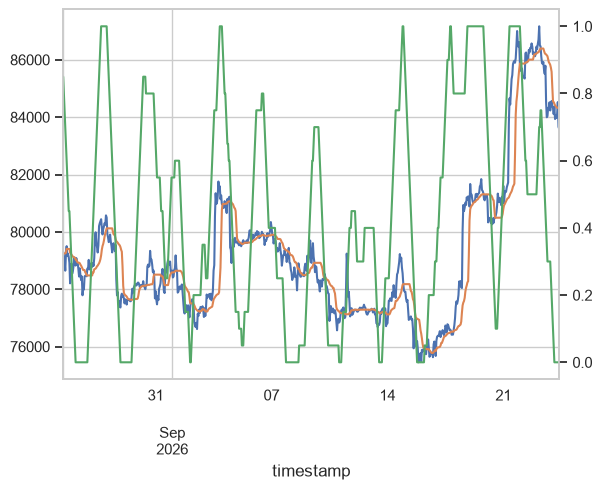

In [7]:
LAST_MONTH_BARS = 24 * 30  # 1 小時 K 線，30 天

ohlcv.close.iloc[-LAST_MONTH_BARS:].plot()
median.iloc[-LAST_MONTH_BARS:].plot()
mmi.iloc[-LAST_MONTH_BARS:].plot(secondary_y=True)

## 把 MMI 加進均線策略：MMI > 0.5 才進場

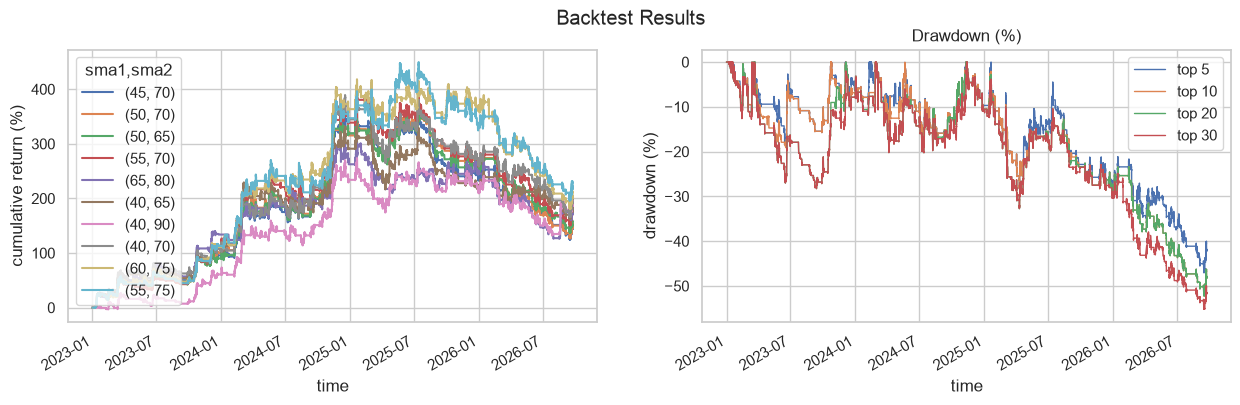

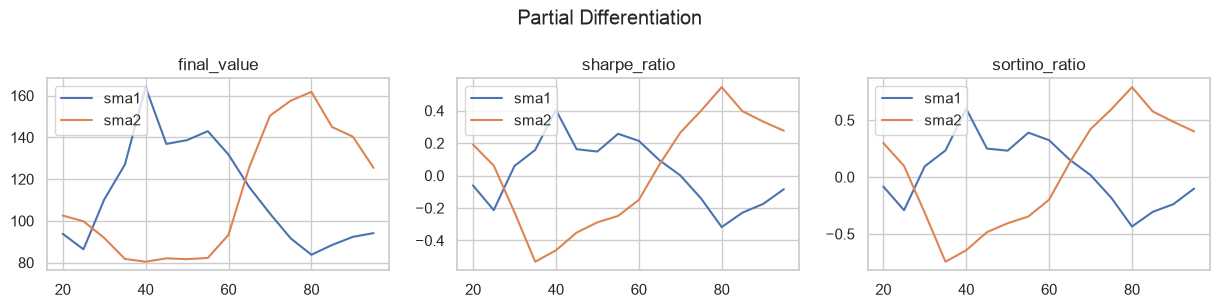

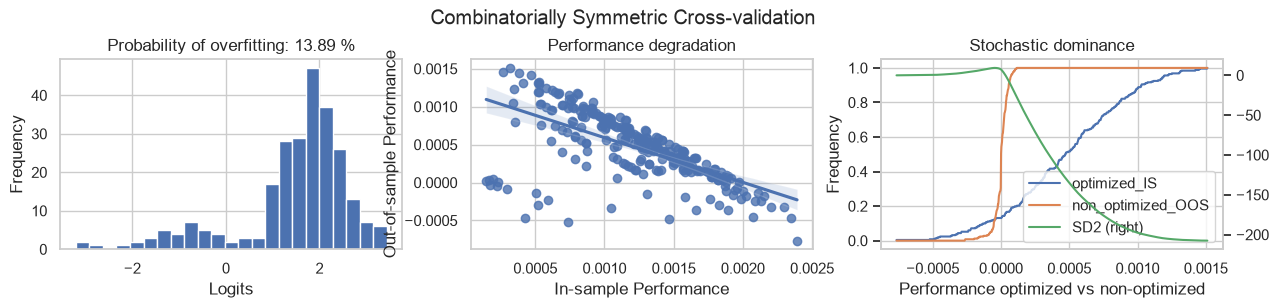

In [8]:
@Strategy(sma1=20, sma2=60)
def mmi_sma_strategy(ohlcv):
    close = ohlcv.close
    sma20 = close.rolling(mmi_sma_strategy.sma1).mean()
    sma60 = close.rolling(mmi_sma_strategy.sma2).mean()

    entries = (sma20 > sma60) & (sma20.shift() < sma60.shift())
    exits = (sma20 < sma60) & (sma20.shift() > sma60.shift())

    figures = {
        'overlaps': {
            'sma20': sma20,
            'sma60': sma60,
        }
    }

    median = ohlcv.close.rolling(20).median()
    p1 = ohlcv.close > median
    p2 = ohlcv.close.shift() > median
    mmi = (p1 & p2).astype(int).rolling(20).mean()

    # 加上濾網條件
    entries = entries & (mmi > 0.5)
    return entries, exits, figures


portfolio = mmi_sma_strategy.backtest(ohlcv, variables=variables, freq='1h', plot=True)

## 5-6 將 Filter 打包重複再利用

用 `@Filter` 把濾網獨立出來，就能套在任何策略上，濾網的參數也能一起最佳化。
`create()` 綁定參數，回傳一個「濾網函式」。

In [9]:
from finlab_crypto import Filter


# 必須給 timeperiod 預設值
@Filter(timeperiod=20)
def mmi_filter(ohlcv):
    median = ohlcv.close.rolling(mmi_filter.timeperiod).median()
    p1 = ohlcv.close > median
    p2 = ohlcv.close.shift() > median
    mmi = (p1 & p2).astype(int).rolling(mmi_filter.timeperiod).mean()

    # 不想畫圖的話 figures = {}
    figures = {
        'figures': {
            'mmi_index': mmi
        }
    }
    return mmi > 0.5, figures


f60 = mmi_filter.create({'timeperiod': 60})
f60(ohlcv)

(timeperiod                    60
 timestamp                       
 2023-01-01 00:00:00+00:00  False
 2023-01-01 01:00:00+00:00  False
 2023-01-01 02:00:00+00:00  False
 2023-01-01 03:00:00+00:00  False
 2023-01-01 04:00:00+00:00  False
 ...                          ...
 2026-09-24 05:00:00+00:00   True
 2026-09-24 06:00:00+00:00   True
 2026-09-24 07:00:00+00:00   True
 2026-09-24 08:00:00+00:00   True
 2026-09-24 09:00:00+00:00   True
 
 [32697 rows x 1 columns],
 {'figures': {'mmi_index': timestamp
   2023-01-01 00:00:00+00:00         NaN
   2023-01-01 01:00:00+00:00         NaN
   2023-01-01 02:00:00+00:00         NaN
   2023-01-01 03:00:00+00:00         NaN
   2023-01-01 04:00:00+00:00         NaN
                                  ...   
   2026-09-24 05:00:00+00:00    0.633333
   2026-09-24 06:00:00+00:00    0.616667
   2026-09-24 07:00:00+00:00    0.600000
   2026-09-24 08:00:00+00:00    0.583333
   2026-09-24 09:00:00+00:00    0.566667
   Name: close, Length: 32697, dtype: flo

### 同時最佳化策略與濾網參數

這格要回測 16 × 16 × 8 = 2048 組參數：本機測試約 4 分鐘，Colab 免費版會更久。
趕時間可以先把上方的 `QUICK_RUN` 改成 `True` 快速看一遍，之後再改回 `False` 看完整結果。

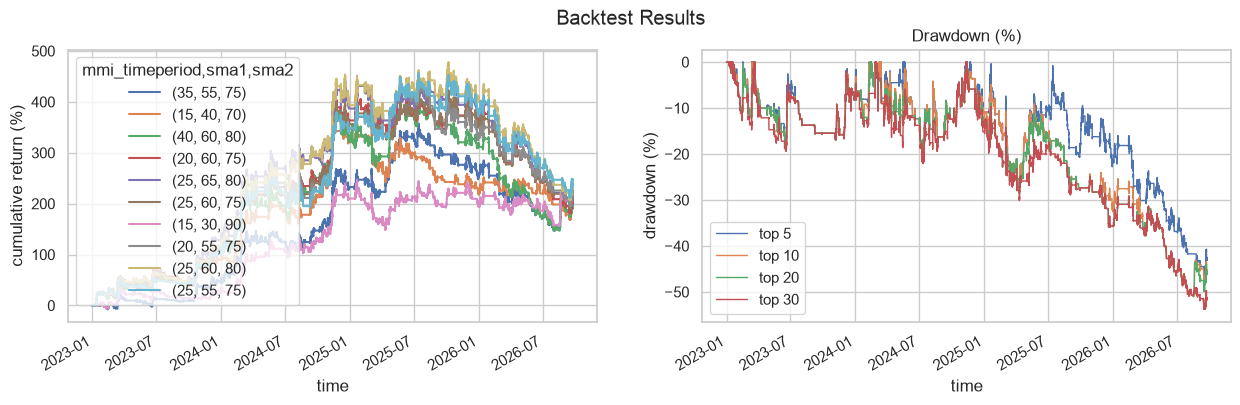

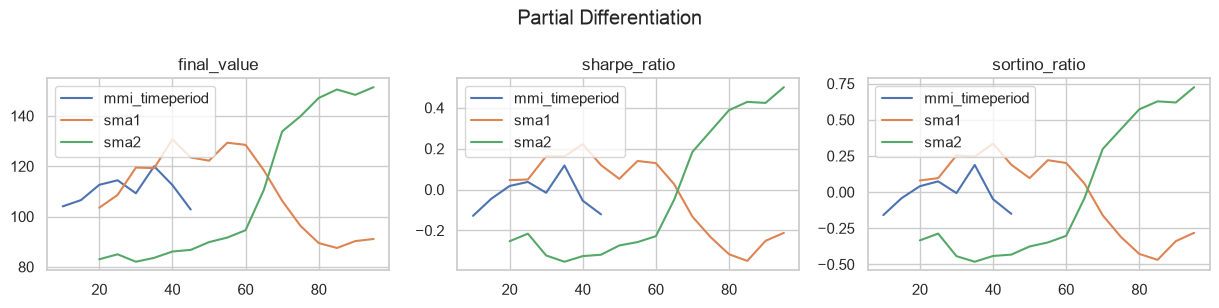

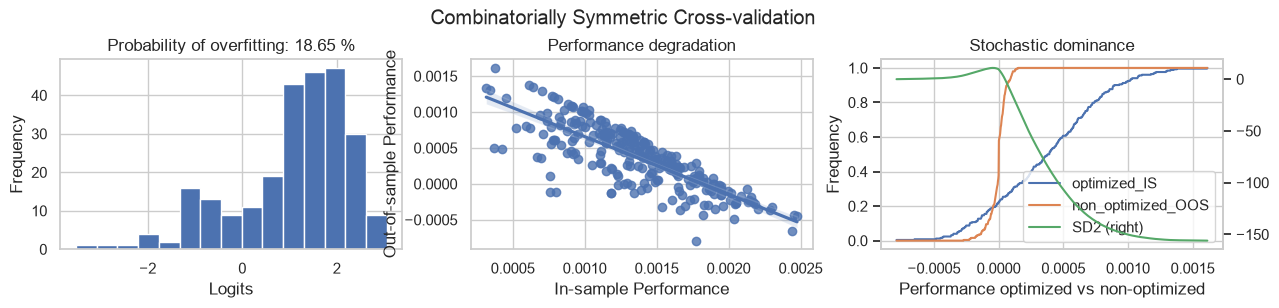

In [10]:
mmi_step = 20 if QUICK_RUN else 5
f_mmi = mmi_filter.create({'timeperiod': np.arange(10, 50, mmi_step)})

# filters 參數放入濾網；欄位名稱會加上濾網名稱前綴，例如 mmi_timeperiod
portfolio = sma_strategy.backtest(ohlcv, variables=variables, filters={'mmi': f_mmi}, freq='1h', plot=True)

### 最終策略

In [11]:
variables = {'sma1': 35, 'sma2': 80}
f_mmi = mmi_filter.create({'timeperiod': 20})

portfolio = sma_strategy.backtest(ohlcv, variables=variables, filters={'mmi': f_mmi}, freq='1h', plot=True)